In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime

In [13]:
df = pd.read_excel('properties_v7_with_ratios.xlsx')
df = df.dropna(subset=['token_ratio'])
df = df[df['is_land'] == 0].copy()          # to exclude land
df = df.dropna(subset=['year_built']).copy() # to drop missing year_built

numeric_cols = [
    'token_ratio', 'annual_cash_flow_lofty', 'annual_cash_flow_calculated', 'projected_annual_cash_flow',
    'average_rental_yield', 'projected_return', 'total_yearly_expenses',
    'underlying_asset_price', 'year_built', 'sqft', 'num_images', 'description_char_len'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['isSellerBuyBack'] = df['isSellerBuyBack'].astype(int)
df['is_land'] = df['is_land'].astype(int)

df['token_fill']= 1-df['token_ratio']
today_str = datetime.today().strftime('%Y-%m-%d %H:%M:%S')
today = pd.to_datetime(today_str)
df['Date'] = pd.to_datetime(df['sellout_date'], format='%m/%d/%y', errors='coerce')
df["days_diff"] = (today - pd.to_datetime(df["Date"])).dt.days

print(f"Final sample: {len(df)} observations\n")

Final sample: 188 observations



In [14]:
df.head()

,property_id,address,city,state,zip_code,asa_id,property_type,sqft,tokens_total,tokens_available,...,sellout_date,isSellerBuyBack,projected_annual_cash_flow,average_rental_yield,is_land,income_source,listing_url,token_fill,Date,days_diff
0,01K1VKTF50B18YPKEKKMNT988E,2820 Rucker Ave,Everett,WA,98201,LFTY0477,commercial,19166,75914,23869,...,2025-08-08,0,149250.00,6.65,0,rent,https://www.lofty.ai/property_deal/2820-Rucker...,0.685578,2025-08-08,289
1,01K1KKTQACRHR32FF2GJAT6WZS,11125 Lawnhaven Rd,Dallas,TX,75230,LFTY0484,single family,2909,36270,1789,...,2025-09-17,0,149250.00,14.52,0,rent,https://www.lofty.ai/property_deal/11125-Lawnh...,0.950675,2025-09-17,249
2,01HH55NJSE80CHPE90B1RTRQRB,88 Madison Ave,Albany,NY,12202,LFTY0314,vacation rental,3032,7455,1285,...,2024-01-29,0,19987.19,14.48,0,rent,https://www.lofty.ai/property_deal/88-Madison-...,0.827632,2024-01-29,846
3,01J4FD23YKCPS1NHKJ75DR9MX6,1317 South Solano Dr,Las Cruces,NM,88001,LFTY0420,commercial,4208,15229,1299,...,2024-08-07,0,59633.16,17.22,0,rent,https://www.lofty.ai/property_deal/1317-South-...,0.914702,2024-08-07,655
4,01JWM9CKG1PV7XH2AJTBKQVFX8,9 Country Club Ln N,Briarcliff Manor,NY,10510,LFTY0476,vacation rental,4151,39213,1289,...,2025-08-15,0,46374.09,6.99,0,rent,https://www.lofty.ai/property_deal/9-Country-C...,0.967128,2025-08-15,282


In [15]:
# Property type dummies
df['is_singlefamily'] = (df['property_type'] == 'single family').astype(int)
df['is_vacation_rental'] = (df['property_type'] == 'vacation rental').astype(int)

In [16]:
# Regional groupings
region_map = {
    'OH': 'Midwest', 'IL': 'Midwest', 'MO': 'Midwest', 'MI': 'Midwest',
    'IA': 'Midwest', 'KS': 'Midwest', 'WI': 'Midwest', 'IN': 'Midwest',
    'TN': 'South',   'FL': 'South',   'TX': 'South',   'AL': 'South',
    'GA': 'South',   'KY': 'South',
    'CA': 'West',    'CO': 'West',    'WA': 'West',    'OR': 'West',
    'AZ': 'West',    'NM': 'West',    'HI': 'West',    'UT': 'West',
    'NY': 'Northeast', 'NJ': 'Northeast', 'VT': 'Northeast',
    'MD': 'Northeast', 'PA': 'Northeast',
}
df['region'] = df['state'].map(region_map).fillna('Other')

print("Region distribution:")
print(df['region'].value_counts(), '\n')

# Region dummies, Midwest is the reference category as it is the largest
df['region_South'] = (df['region'] == 'South').astype(int)
df['region_West'] = (df['region'] == 'West').astype(int)
df['region_Northeast'] = (df['region'] == 'Northeast').astype(int)

Region distribution:
region
Midwest      112
South         44
West          21
Northeast     11
Name: count, dtype: int64 



In [17]:
feature_cols = [
    'year_built',
    'sqft',
    'is_singlefamily',
    'is_vacation_rental',
    'isSellerBuyBack',
    'region_South',
    'region_West',
    'region_Northeast',
]

X = df[feature_cols].copy()
y = df['token_fill'].copy()
 
X_const = sm.add_constant(X)

In [30]:
model_a1 = sm.OLS(y, X_const).fit()
print("=" * 60)
print("MODEL A1 - Property Characteristics")
print("=" * 60)
print(model_a1.summary())

MODEL A1 — Property Characteristics
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.8447
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.565
Time:                        19:23:40   Log-Likelihood:                 262.04
No. Observations:                 188   AIC:                            -506.1
Df Residuals:                     179   BIC:                            -477.0
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------


In [18]:
feature_cols = [
    'year_built',
    'sqft',
    'is_singlefamily',
    'is_vacation_rental',
    'isSellerBuyBack'
]

X = df[feature_cols].copy()
y = df['token_fill'].copy()
 
X_const = sm.add_constant(X)

In [32]:
model_a2 = sm.OLS(y, X_const).fit()
print("=" * 60)
print("MODEL A2 — Property Characteristics (without region dummies)")
print("=" * 60)
print(model_a2.summary())

MODEL A2 — Property Characteristics (without region dummies)
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.035
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.399
Time:                        19:23:57   Log-Likelihood:                 261.19
No. Observations:                 188   AIC:                            -510.4
Df Residuals:                     182   BIC:                            -491.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [19]:
from scipy.stats import zscore
df['year_built_z'] = zscore(df['year_built'])
df['sqft_z'] = zscore(df['sqft'])

feature_cols = [
    'year_built_z',
    'sqft_z',
    'is_singlefamily',
    'is_vacation_rental',
    'isSellerBuyBack',
    'region_South',
    'region_West',
    'region_Northeast',
]

X = df[feature_cols].copy()
y = df['token_fill'].copy()
 
X_const = sm.add_constant(X)

In [33]:
model_a3 = sm.OLS(y, X_const).fit()
print("=" * 60)
print("MODEL A3 — Property Characteristics (with region dummies + z-score sqft and year_built)")
print("=" * 60)
print(model_a3.summary())

MODEL A3 — Property Characteristics (with region dummies + z-score sqft and year_built)
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.8447
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.565
Time:                        19:24:29   Log-Likelihood:                 262.04
No. Observations:                 188   AIC:                            -506.1
Df Residuals:                     179   BIC:                            -477.0
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

In [34]:
feature_cols = [
    'year_built_z',
    'sqft_z',
    'is_singlefamily',
    'is_vacation_rental',
    'isSellerBuyBack'
]

X = df[feature_cols].copy()
y = df['token_fill'].copy()
 
X_const = sm.add_constant(X)

model_a4 = sm.OLS(y, X_const).fit()
print("=" * 60)
print("MODEL A4 — Property Characteristics (without region dummies, includes z-score sqft and year_built)")
print("=" * 60)
print(model_a4.summary())

MODEL A4 — Property Characteristics (without region dummies, includes z-score sqft and year_built)
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.035
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.399
Time:                        19:24:36   Log-Likelihood:                 261.19
No. Observations:                 188   AIC:                            -510.4
Df Residuals:                     182   BIC:                            -491.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------

In [35]:
feature_cols = [
    'year_built_z',
    'sqft_z'
]

X = df[feature_cols].copy()
y = df['token_fill'].copy()
 
X_const = sm.add_constant(X)

model_a5 = sm.OLS(y, X_const).fit(cov_type='HC3')
print("=" * 60)
print("MODEL A5 — Property Characteristics")
print("=" * 60)
print(model_a5.summary())

MODEL A5 — Property Characteristics
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     2.182
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.116
Time:                        19:24:45   Log-Likelihood:                 260.64
No. Observations:                 188   AIC:                            -515.3
Df Residuals:                     185   BIC:                            -505.6
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const       

In [36]:
print(df['year_built'].mean())
print(df['sqft'].mean())

1943.6968085106382
4231.734042553191


In [37]:
print("Variance Inflation Factors")
vif_df = pd.DataFrame({
    'Variable': feature_cols,
    'VIF': [variance_inflation_factor(X_const.values, i + 1)
            for i in range(len(feature_cols))]
}).sort_values('VIF', ascending=False)
print(vif_df.to_string(index=False))

Variance Inflation Factors
    Variable      VIF
year_built_z 1.007239
      sqft_z 1.007239


In [38]:
print("Linearity, Pearson r")
for col in ['year_built_z', 'sqft_z']:
    r, p = stats.pearsonr(df[col], y)
    print(f" {col}: r = {r:.4f}, p = {p:.4f}")

Linearity, Pearson r
  year_built_z: r = 0.1475, p = 0.0434
  sqft_z: r = 0.0256, p = 0.7274


In [39]:
print("Outliers - Cook's Distance")
n_a5 = len(y)
influence   = model_a5.get_influence()
cooks_d     = influence.cooks_distance[0]
leverage    = influence.hat_matrix_diag
threshold   = 4 / n_a5
n_outliers  = (cooks_d > threshold).sum()
top5_idx    = np.argsort(cooks_d)[::-1][:5]
print(f"  Threshold (4/n = 4/{n_a5}): {threshold:.4f}")
print(f"  Observations exceeding threshold: {n_outliers}")
print(f"  Top 5 Cook's D:")
for i in top5_idx:
    print(f"    Obs {i:>4} | Cook's D = {cooks_d[i]:.4f} | "
          f"property_id = {df['property_id'].iloc[i]} | "
          f"token_fill = {y.iloc[i]:.4f} | "
          f"year_built = {df['year_built'].iloc[i]:.0f} | "
          f"sqft = {df['sqft'].iloc[i]:.0f}")

Outliers - Cook's Distance
  Threshold (4/n = 4/188): 0.0213
  Observations exceeding threshold: 8
  Top 5 Cook's D:
    Obs  132 | Cook's D = 8.2155 | property_id = 01FMDJ818RZTM1WQEKN9Z7GXGY | token_fill = 1.0000 | year_built = 1978 | sqft = 304920
    Obs    0 | Cook's D = 0.0892 | property_id = 01K1VKTF50B18YPKEKKMNT988E | token_fill = 0.6856 | year_built = 1902 | sqft = 19166
    Obs    2 | Cook's D = 0.0619 | property_id = 01HH55NJSE80CHPE90B1RTRQRB | token_fill = 0.8276 | year_built = 1815 | sqft = 3032
    Obs   75 | Cook's D = 0.0451 | property_id = 01G6HB0G3MK5ND2Z184FFVNT6Z | token_fill = 0.7270 | year_built = 1906 | sqft = 1130
    Obs   65 | Cook's D = 0.0364 | property_id = 01JQ7E3CEJ2727DYEWSHJP9V29 | token_fill = 0.9024 | year_built = 1995 | sqft = 84071


In [40]:
from statsmodels.stats.diagnostic import het_breuschpagan
fitted_a5 = model_a5.fittedvalues
residuals_a5 = model_a5.resid
std_resid_a5 = residuals_a5 / residuals_a5.std()
n_a5 = len(y)

print("Equal Spread (Homoscedasticity)")
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(residuals_a5, X_const)
print(f"  Breusch-Pagan LM statistic: {bp_lm:.4f}, p-value: {bp_lm_p:.4f}")
print(f"  {'Heteroscedasticity detected (p<0.05)' if bp_lm_p < 0.05 else 'No significant heteroscedasticity at 5% level'}")

Equal Spread (Homoscedasticity)
  Breusch-Pagan LM statistic: 5.6049, p-value: 0.0607
  No significant heteroscedasticity at 5% level


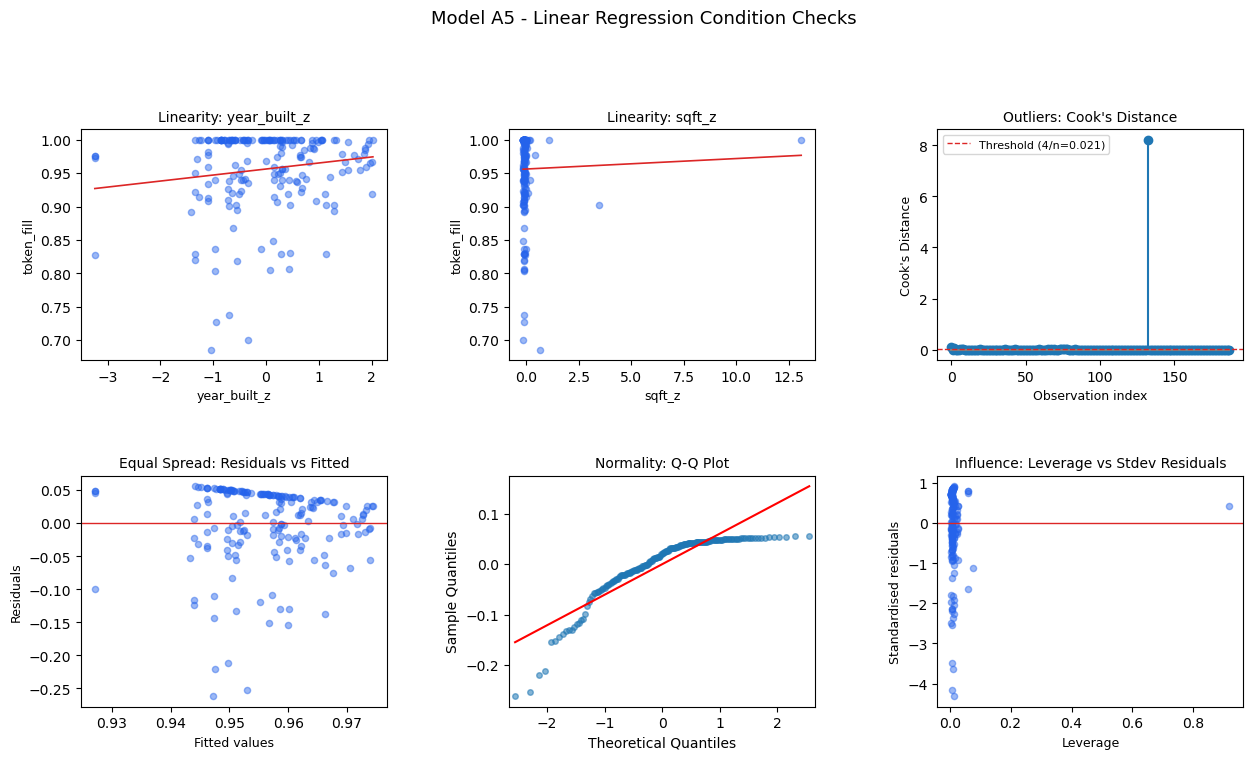

In [41]:
fig2 = plt.figure(figsize=(15, 12))
fig2.suptitle('Model A5 - Linear Regression Condition Checks', fontsize=13, y=0.98)
gs2 = gridspec.GridSpec(3, 3, figure=fig2, hspace=0.5, wspace=0.4)
 
# Linearity: y vs year_built_z
ax1 = fig2.add_subplot(gs2[0, 0])
ax1.scatter(df['year_built_z'], y, alpha=0.45, s=20, color='#2563eb')
m, b = np.polyfit(df['year_built_z'], y, 1)
xr = np.linspace(df['year_built_z'].min(), df['year_built_z'].max(), 100)
ax1.plot(xr, m * xr + b, color='#dc2626', linewidth=1.2)
ax1.set_xlabel('year_built_z', fontsize=9)
ax1.set_ylabel('token_fill', fontsize=9)
ax1.set_title('Linearity: year_built_z', fontsize=10)
 
# Linearity: y vs sqft_z
ax2 = fig2.add_subplot(gs2[0, 1])
ax2.scatter(df['sqft_z'], y, alpha=0.45, s=20, color='#2563eb')
m2, b2 = np.polyfit(df['sqft_z'], y, 1)
xr2 = np.linspace(df['sqft_z'].min(), df['sqft_z'].max(), 100)
ax2.plot(xr2, m2 * xr2 + b2, color='#dc2626', linewidth=1.2)
ax2.set_xlabel('sqft_z', fontsize=9)
ax2.set_ylabel('token_fill', fontsize=9)
ax2.set_title('Linearity: sqft_z', fontsize=10)
 
# Outliers: Cook's distance
influence = model_a5.get_influence()
cooks_d = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag
threshold = 4 / n_a5
n_outliers = (cooks_d > threshold).sum()
top5_idx = np.argsort(cooks_d)[::-1][:5]
ax4 = fig2.add_subplot(gs2[0, 2])
ax4.stem(range(n_a5), cooks_d, markerfmt='o', linefmt='C0-', basefmt='gray')
ax4.axhline(threshold, color='#dc2626', linewidth=1,
            linestyle='--', label=f'Threshold (4/n={threshold:.3f})')
ax4.set_xlabel('Observation index', fontsize=9)
ax4.set_ylabel("Cook's Distance", fontsize=9)
ax4.set_title("Outliers: Cook's Distance", fontsize=10)
ax4.legend(fontsize=8)
 
# Equal spread: Residuals vs Fitted
ax5 = fig2.add_subplot(gs2[1, 0])
ax5.scatter(fitted_a5, residuals_a5, alpha=0.45, s=20, color='#2563eb')
ax5.axhline(0, color='#dc2626', linewidth=1)
ax5.set_xlabel('Fitted values', fontsize=9)
ax5.set_ylabel('Residuals', fontsize=9)
ax5.set_title('Equal Spread: Residuals vs Fitted', fontsize=10)
 
# Normality: Q-Q plot
ax7 = fig2.add_subplot(gs2[1, 1])
sm.qqplot(residuals_a5, line='s', ax=ax7, alpha=0.55, markersize=4)
ax7.set_title('Normality: Q-Q Plot', fontsize=10)
 
# Influence: Leverage vs Std residuals
ax8 = fig2.add_subplot(gs2[1, 2])
ax8.scatter(leverage, std_resid_a5, alpha=0.45, s=20, color='#2563eb')
ax8.axhline(0, color='#dc2626', linewidth=1)
ax8.set_xlabel('Leverage', fontsize=9)
ax8.set_ylabel('Standardised residuals', fontsize=9)
ax8.set_title('Influence: Leverage vs Stdev Residuals', fontsize=10)
plt.savefig("modela.png")

In [20]:
df = pd.read_excel('properties_v7_with_ratios.xlsx')
df = df.dropna(subset=['token_ratio'])
df = df[df['is_land'] == 0].copy()          # to exclude land
df = df.dropna(subset=['year_built']).copy() # to drop missing year_built

numeric_cols = [
    'token_ratio', 'annual_cash_flow_lofty', 'annual_cash_flow_calculated', 'projected_annual_cash_flow',
    'average_rental_yield', 'projected_return', 'total_yearly_expenses',
    'underlying_asset_price', 'year_built', 'sqft', 'num_images', 'description_char_len'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['isSellerBuyBack'] = df['isSellerBuyBack'].astype(int)
df['is_land'] = df['is_land'].astype(int)

df['token_fill']= 1-df['token_ratio']
today_str = datetime.today().strftime('%Y-%m-%d %H:%M:%S')
today = pd.to_datetime(today_str)
df['Date'] = pd.to_datetime(df['sellout_date'], format='%m/%d/%y', errors='coerce')
df["days_diff"] = (today - pd.to_datetime(df["Date"])).dt.days
 
print(f"Final sample: {len(df)} observations\n")

Final sample: 188 observations



In [21]:
feature_cols = [
    'annual_cash_flow_lofty',
    'annual_cash_flow_calculated',
    'projected_annual_cash_flow',
    'average_rental_yield',
    'projected_return',
    'total_yearly_expenses',
    'underlying_asset_price',
]
for col in feature_cols:
    df[f'{col}_z'] = zscore(df[col])
 
y = df['token_fill'].copy()

In [46]:
feature_cols_b1 = [
    'annual_cash_flow_lofty_z',
    'projected_return_z',
    'total_yearly_expenses_z',
    'underlying_asset_price_z',
]
 
X_b1 = df[feature_cols_b1].copy()
X_b1_const = sm.add_constant(X_b1)
model_b1 = sm.OLS(y, X_b1_const).fit(cov_type='HC3')
 
print("\n" + "=" * 65)
print("MODEL B1 - Financial Variables, including annual_cash_flow")
print("=" * 65)
print(model_b1.summary())


MODEL B1 - Financial Variables, including annual_cash_flow
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.086
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.365
Time:                        19:27:01   Log-Likelihood:                 260.81
No. Observations:                 188   AIC:                            -511.6
Df Residuals:                     183   BIC:                            -495.4
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

In [47]:
feature_cols_b2 = [
    'projected_annual_cash_flow_z',
    'projected_return_z',
    'total_yearly_expenses_z',
    'underlying_asset_price_z',
]
 
X_b2 = df[feature_cols_b2].copy()
X_b2_const = sm.add_constant(X_b2)
model_b2 = sm.OLS(y, X_b2_const).fit(cov_type='HC3')
 
print("\n" + "=" * 65)
print("MODEL B2 — Financial Variables, including projected_annual_cash_flow")
print("=" * 65)
print(model_b2.summary())


MODEL B2 — Financial Variables, including projected_annual_cash_flow
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.133
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.343
Time:                        19:27:09   Log-Likelihood:                 260.92
No. Observations:                 188   AIC:                            -511.8
Df Residuals:                     183   BIC:                            -495.7
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------

In [48]:
feature_cols_b3 = [
    'annual_cash_flow_calculated_z',
    'projected_return_z',
    'total_yearly_expenses_z',
    'underlying_asset_price_z',
]
 
X_b3 = df[feature_cols_b3].copy()
X_b3_const = sm.add_constant(X_b3)
model_b3 = sm.OLS(y, X_b3_const).fit(cov_type='HC3')
 
print("\n" + "=" * 65)
print("MODEL B3 — Financial Variables, including annual_cash_flow_calculated")
print("=" * 65)
print(model_b3.summary())


MODEL B3 — Financial Variables, including annual_cash_flow_calculated
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                     1.110
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.353
Time:                        19:27:13   Log-Likelihood:                 260.30
No. Observations:                 188   AIC:                            -510.6
Df Residuals:                     183   BIC:                            -494.4
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

In [49]:
feature_cols_b4 = [
    'projected_annual_cash_flow_z',
    'projected_return_z',
    'total_yearly_expenses_z'
]
 
X_b4 = df[feature_cols_b4].copy()
X_b4_const = sm.add_constant(X_b4)
model_b4 = sm.OLS(y, X_b4_const).fit(cov_type='HC3')
 
print("\n" + "=" * 65)
print("MODEL B4 — Financial Variables, including projected_annual_cash_flow")
print("=" * 65)
print(model_b4.summary())


MODEL B4 — Financial Variables, including projected_annual_cash_flow
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1.407
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.242
Time:                        19:27:18   Log-Likelihood:                 260.90
No. Observations:                 188   AIC:                            -513.8
Df Residuals:                     184   BIC:                            -500.9
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------

In [50]:
print(df['projected_annual_cash_flow'].mean())
print(df['projected_return'].mean())
print(df['total_yearly_expenses'].mean())

20162.775638297873
10.659627659574467
19015.09095744681


In [51]:
print("Variance Inflation Factors")
vif_df = pd.DataFrame({
    'Variable': feature_cols_b4,
    'VIF': [variance_inflation_factor(X_b4_const.values, i + 1)
            for i in range(len(feature_cols_b4))]
}).sort_values('VIF', ascending=False)
print(vif_df.to_string(index=False))

Variance Inflation Factors
                    Variable      VIF
projected_annual_cash_flow_z 1.375075
          projected_return_z 1.200256
     total_yearly_expenses_z 1.163947


In [52]:
print("Linearity, Pearson r")
for col in ['projected_annual_cash_flow_z', 'projected_return_z', 'total_yearly_expenses_z']:
    r, p = stats.pearsonr(df[col], y)
    print(f"  {col}: r = {r:.4f}, p = {p:.4f}")

Linearity, Pearson r
  projected_annual_cash_flow_z: r = -0.0348, p = 0.6351
  projected_return_z: r = 0.1038, p = 0.1562
  total_yearly_expenses_z: r = 0.0585, p = 0.4252


In [53]:
fitted_b4 = model_b4.fittedvalues
residuals_b4 = model_b4.resid
std_resid_b4 = residuals_b4 / residuals_b4.std()
n_b4 = len(y)

print("Equal Spread (Homoscedasticity)")
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(residuals_b4, X_b4_const)
print(f"  Breusch-Pagan LM statistic: {bp_lm:.4f}, p-value: {bp_lm_p:.4f}")
print(f"  {'Heteroscedasticity detected (p<0.05)' if bp_lm_p < 0.05 else 'No significant heteroscedasticity at 5% level'}")

Equal Spread (Homoscedasticity)
  Breusch-Pagan LM statistic: 6.1843, p-value: 0.1030
  No significant heteroscedasticity at 5% level


  Threshold (4/n = 4/188): 0.0213
  Observations exceeding threshold: 8
  Top 5 Cook's D:
    Obs    0 | Cook's D = 1.1758 | property_id = 01K1VKTF50B18YPKEKKMNT988E | token_fill = 0.6856 | projected_return = 7.7000
    Obs    7 | Cook's D = 0.1310 | property_id = 01HW421V0876XEFDHBT50NXB2W | token_fill = 0.8282 | projected_return = 8.2700
    Obs    2 | Cook's D = 0.0570 | property_id = 01HH55NJSE80CHPE90B1RTRQRB | token_fill = 0.8276 | projected_return = 11.9200
    Obs   77 | Cook's D = 0.0333 | property_id = 01FKPEZVFSD6KDYN5DY5Y7Z2AE | token_fill = 0.6999 | projected_return = 7.9600
    Obs   75 | Cook's D = 0.0259 | property_id = 01G6HB0G3MK5ND2Z184FFVNT6Z | token_fill = 0.7270 | projected_return = 8.3600


/var/folders/j4/c8mt230n6rn5t0qj3jl08r3m0000gn/T/ipykernel_2472/3659642849.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


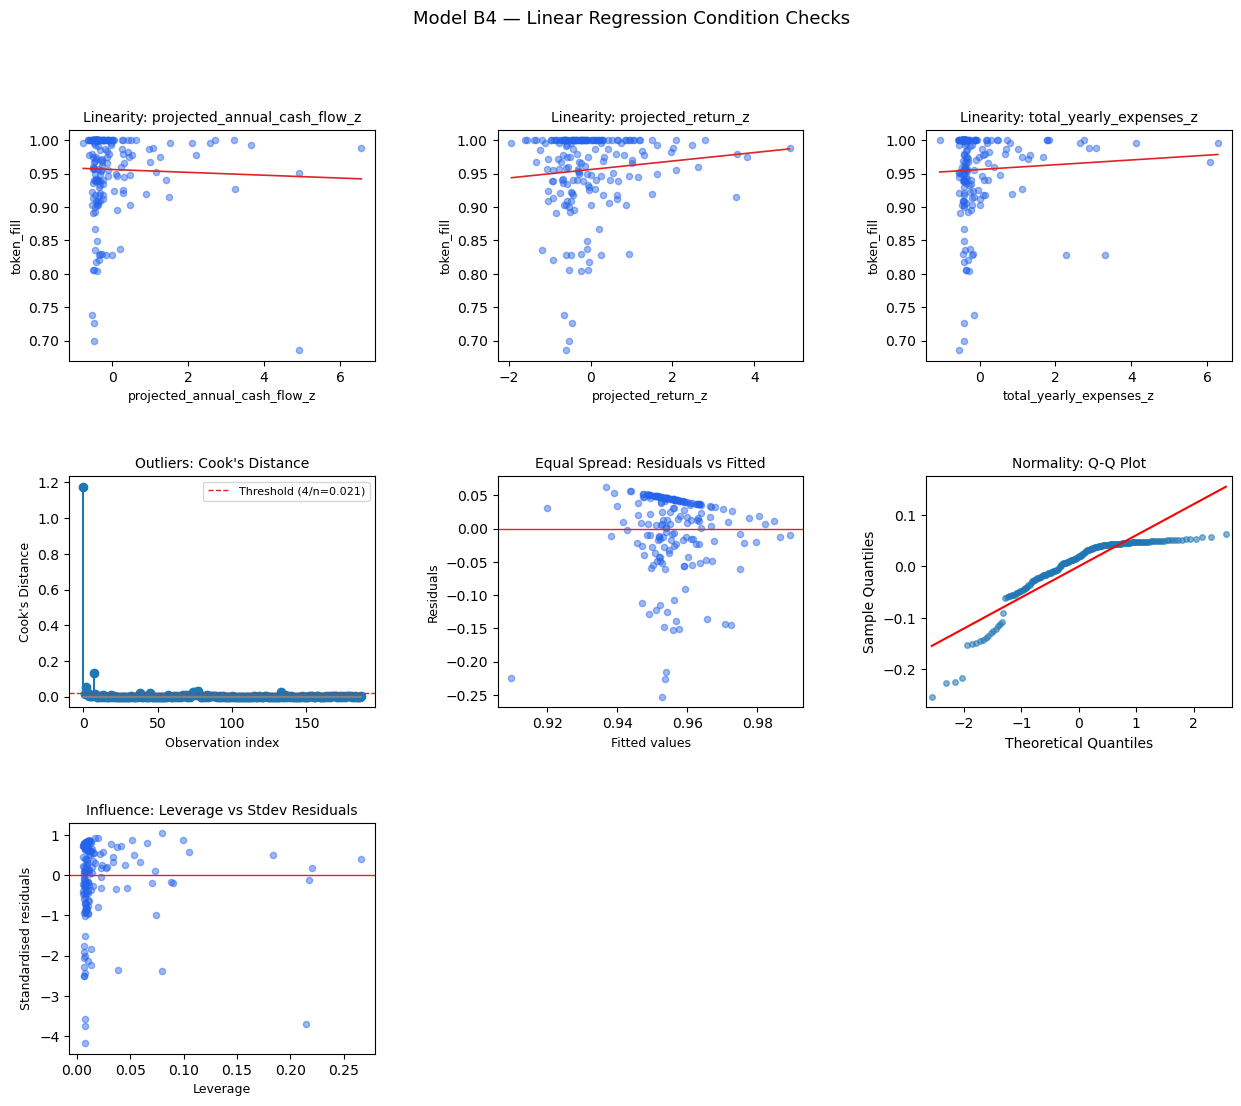

In [54]:
fitted_b4 = model_b4.fittedvalues
residuals_b4 = model_b4.resid
std_resid_b4 = residuals_b4 / residuals_b4.std()
n_b4 = len(y)
bins_b4 = pd.qcut(fitted_b4, q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

influence_b4 = model_b4.get_influence()
cooks_d_b4 = influence_b4.cooks_distance[0]
leverage_b4 = influence_b4.hat_matrix_diag
threshold_b4 = 4 / n_b4

print(f"  Threshold (4/n = 4/{n_b4}): {threshold_b4:.4f}")
print(f"  Observations exceeding threshold: {(cooks_d_b4 > threshold_b4).sum()}")
print(f"  Top 5 Cook's D:")
for i in np.argsort(cooks_d_b4)[::-1][:5]:
    print(f"    Obs {i:>4} | Cook's D = {cooks_d_b4[i]:.4f} | "
          f"property_id = {df['property_id'].iloc[i]} | "
          f"token_fill = {y.iloc[i]:.4f} | "
          f"projected_return = {df['projected_return'].iloc[i]:.4f}")

fig2 = plt.figure(figsize=(15, 12))
fig2.suptitle('Model B4 — Linear Regression Condition Checks', fontsize=13, y=0.98)
gs2 = gridspec.GridSpec(3, 3, figure=fig2, hspace=0.5, wspace=0.4)

# Linearity: y vs projected_annual_cash_flow_z
ax1 = fig2.add_subplot(gs2[0, 0])
ax1.scatter(df['projected_annual_cash_flow_z'], y, alpha=0.45, s=20, color='#2563eb')
m, b = np.polyfit(df['projected_annual_cash_flow_z'], y, 1)
xr = np.linspace(df['projected_annual_cash_flow_z'].min(), df['projected_annual_cash_flow_z'].max(), 100)
ax1.plot(xr, m * xr + b, color='#dc2626', linewidth=1.2)
ax1.set_xlabel('projected_annual_cash_flow_z', fontsize=9)
ax1.set_ylabel('token_fill', fontsize=9)
ax1.set_title('Linearity: projected_annual_cash_flow_z', fontsize=10)

# Linearity: y vs projected_return_z
ax2 = fig2.add_subplot(gs2[0, 1])
ax2.scatter(df['projected_return_z'], y, alpha=0.45, s=20, color='#2563eb')
m2, b2 = np.polyfit(df['projected_return_z'], y, 1)
xr2 = np.linspace(df['projected_return_z'].min(), df['projected_return_z'].max(), 100)
ax2.plot(xr2, m2 * xr2 + b2, color='#dc2626', linewidth=1.2)
ax2.set_xlabel('projected_return_z', fontsize=9)
ax2.set_ylabel('token_fill', fontsize=9)
ax2.set_title('Linearity: projected_return_z', fontsize=10)

# Linearity: y vs total_yearly_expenses_z
ax3 = fig2.add_subplot(gs2[0, 2])
ax3.scatter(df['total_yearly_expenses_z'], y, alpha=0.45, s=20, color='#2563eb')
m3, b3 = np.polyfit(df['total_yearly_expenses_z'], y, 1)
xr3 = np.linspace(df['total_yearly_expenses_z'].min(), df['total_yearly_expenses_z'].max(), 100)
ax3.plot(xr3, m3 * xr3 + b3, color='#dc2626', linewidth=1.2)
ax3.set_xlabel('total_yearly_expenses_z', fontsize=9)
ax3.set_ylabel('token_fill', fontsize=9)
ax3.set_title('Linearity: total_yearly_expenses_z', fontsize=10)

# Outliers: Cook's distance
ax4 = fig2.add_subplot(gs2[1, 0])
ax4.stem(range(n_b4), cooks_d_b4, markerfmt='o', linefmt='C0-', basefmt='gray')
ax4.axhline(threshold_b4, color='#dc2626', linewidth=1,
            linestyle='--', label=f'Threshold (4/n={threshold_b4:.3f})')
ax4.set_xlabel('Observation index', fontsize=9)
ax4.set_ylabel("Cook's Distance", fontsize=9)
ax4.set_title("Outliers: Cook's Distance", fontsize=10)
ax4.legend(fontsize=8)

# Equal spread: Residuals vs Fitted
ax5 = fig2.add_subplot(gs2[1, 1])
ax5.scatter(fitted_b4, residuals_b4, alpha=0.45, s=20, color='#2563eb')
ax5.axhline(0, color='#dc2626', linewidth=1)
ax5.set_xlabel('Fitted values', fontsize=9)
ax5.set_ylabel('Residuals', fontsize=9)
ax5.set_title('Equal Spread: Residuals vs Fitted', fontsize=10)

# Normality: Q-Q plot
ax7 = fig2.add_subplot(gs2[1, 2])
sm.qqplot(residuals_b4, line='s', ax=ax7, alpha=0.55, markersize=4)
ax7.set_title('Normality: Q-Q Plot', fontsize=10)

# Influence: Leverage vs Stdev residuals
ax8 = fig2.add_subplot(gs2[2, 0])
ax8.scatter(leverage_b4, std_resid_b4, alpha=0.45, s=20, color='#2563eb')
ax8.axhline(0, color='#dc2626', linewidth=1)
ax8.set_xlabel('Leverage', fontsize=9)
ax8.set_ylabel('Standardised residuals', fontsize=9)
ax8.set_title('Influence: Leverage vs Stdev Residuals', fontsize=10)

plt.tight_layout()
plt.savefig("modelb4.png")
plt.show()

In [55]:
df['num_images_z'] = zscore(df['num_images'])
df['description_char_len_z'] = zscore(df['description_char_len'])
 
y = df['token_fill'].copy()

In [56]:
feature_cols_c = ['num_images_z', 'description_char_len_z']
 
X_c = df[feature_cols_c].copy()
X_c_const = sm.add_constant(X_c)

model_c = sm.OLS(y, X_c_const).fit(cov_type='HC3')
 
print("\n" + "=" * 60)
print("MODEL C — Listing Quality")
print("=" * 60)
print(model_c.summary())


MODEL C — Listing Quality
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                     1.636
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.198
Time:                        19:28:14   Log-Likelihood:                 259.40
No. Observations:                 188   AIC:                            -512.8
Df Residuals:                     185   BIC:                            -503.1
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
c

In [57]:
print(df['num_images'].mean())
print(df['description_char_len'].mean())

30.164893617021278
4760.835106382979


In [58]:
print("Variance Inflation Factors")
vif_c = pd.DataFrame({
    'Variable': feature_cols_c,
    'VIF': [variance_inflation_factor(X_c_const.values, i + 1)
            for i in range(len(feature_cols_c))]
}).sort_values('VIF', ascending=False)
print(vif_c.to_string(index=False))

Variance Inflation Factors
              Variable      VIF
description_char_len_z 1.021143
          num_images_z 1.021143


In [59]:
print("Linearity, Pearson r")
for col in ['num_images_z', 'description_char_len']:
    r, p = stats.pearsonr(df[col], y)
    print(f"  {col}: r = {r:.4f}, p = {p:.4f}")

Linearity, Pearson r
  num_images_z: r = 0.0941, p = 0.1988
  description_char_len: r = -0.0075, p = 0.9181


In [60]:
fitted_c = model_c.fittedvalues
residuals_c = model_c.resid
std_resid_c = residuals_c / residuals_c.std()
n_c = len(y)

print("Equal Spread (Homoscedasticity)")
bp_lm, bp_lm_p, _, _ = het_breuschpagan(residuals_c, X_c_const)
print(f"  Breusch-Pagan LM: {bp_lm:.4f}, p-value: {bp_lm_p:.4f}")
print(f"  {'Heteroscedasticity detected (p<0.05)' if bp_lm_p < 0.05 else 'No significant heteroscedasticity at 5% level'}")

Equal Spread (Homoscedasticity)
  Breusch-Pagan LM: 1.2183, p-value: 0.5438
  No significant heteroscedasticity at 5% level


In [61]:
print("Outliers — Cook's Distance")
influence_c = model_c.get_influence()
cooks_d_c = influence_c.cooks_distance[0]
leverage_c = influence_c.hat_matrix_diag
threshold_c = 4 / n_c
print(f"  Threshold (4/n = 4/{n_c}): {threshold_c:.4f}")
print(f"  Observations exceeding threshold: {(cooks_d_c > threshold_c).sum()}")
print(f"  Top 5 Cook's D:")
for i in np.argsort(cooks_d_c)[::-1][:5]:
    print(f"    Obs {i:>4} | Cook's D = {cooks_d_c[i]:.4f} | "
          f"property_id = {df['property_id'].iloc[i]} | "
          f"token_fill = {y.iloc[i]:.4f} | "
          f"num_images = {df['num_images'].iloc[i]:.0f} | "
          f"desc_len = {df['description_char_len'].iloc[i]:.0f}")

Outliers — Cook's Distance
  Threshold (4/n = 4/188): 0.0213
  Observations exceeding threshold: 7
  Top 5 Cook's D:
    Obs   76 | Cook's D = 0.0785 | property_id = 01FQ0P6Z9ZFM7A7AB22358MTDY | token_fill = 0.8289 | num_images = 19 | desc_len = 40874
    Obs   85 | Cook's D = 0.0657 | property_id = 01FKER0A73QJBYP4JQHW10KYBH | token_fill = 0.9028 | num_images = 12 | desc_len = 77442
    Obs   77 | Cook's D = 0.0641 | property_id = 01FKPEZVFSD6KDYN5DY5Y7Z2AE | token_fill = 0.6999 | num_images = 10 | desc_len = 270
    Obs   71 | Cook's D = 0.0503 | property_id = 01FJG0QAVSKK1MQWZ28XXVXSPB | token_fill = 0.8359 | num_images = 15 | desc_len = 35201
    Obs    0 | Cook's D = 0.0489 | property_id = 01K1VKTF50B18YPKEKKMNT988E | token_fill = 0.6856 | num_images = 43 | desc_len = 2240


/var/folders/j4/c8mt230n6rn5t0qj3jl08r3m0000gn/T/ipykernel_2472/2410336098.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


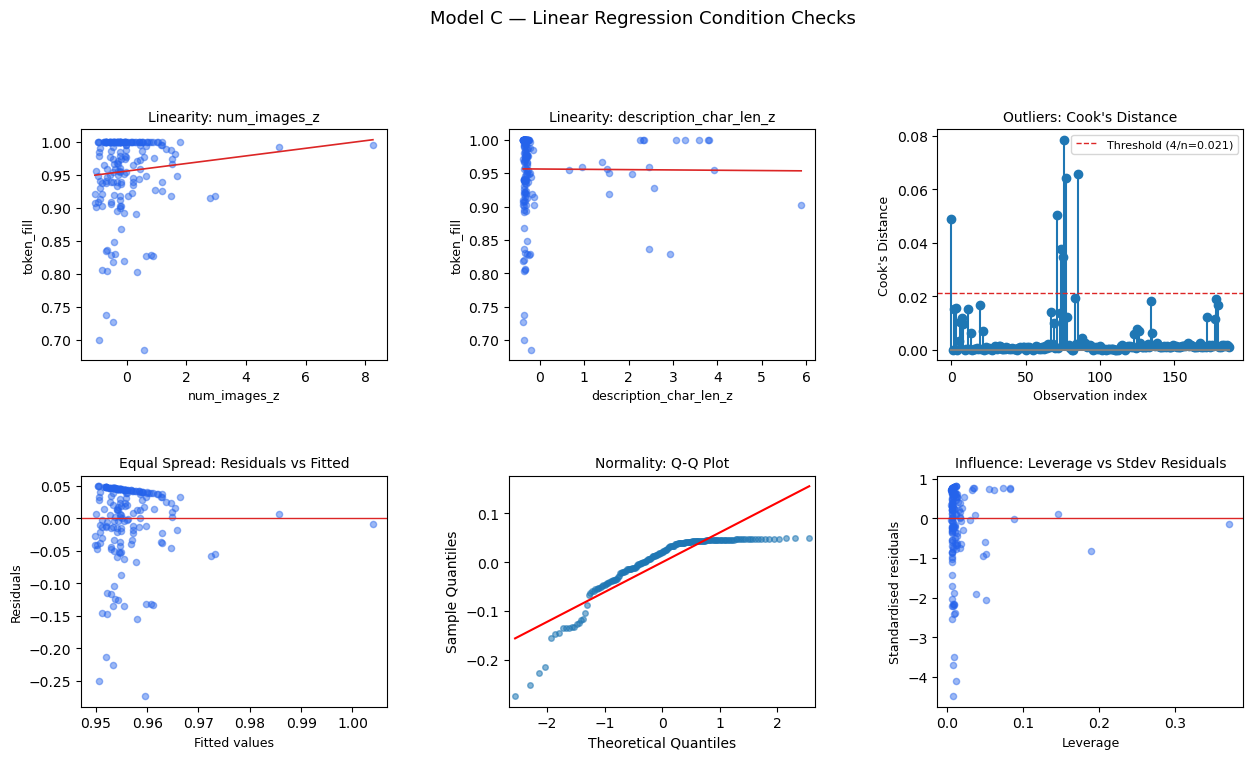

In [62]:
bins_c = pd.qcut(fitted_c, q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

fig = plt.figure(figsize=(15, 12))
fig.suptitle('Model C — Linear Regression Condition Checks', fontsize=13, y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)
 
# Linearity: y vs num_images_z
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(df['num_images_z'], y, alpha=0.45, s=20, color='#2563eb')
m, b = np.polyfit(df['num_images_z'], y, 1)
xr = np.linspace(df['num_images_z'].min(), df['num_images_z'].max(), 100)
ax1.plot(xr, m * xr + b, color='#dc2626', linewidth=1.2)
ax1.set_xlabel('num_images_z', fontsize=9)
ax1.set_ylabel('token_fill', fontsize=9)
ax1.set_title('Linearity: num_images_z', fontsize=10)
 
# Linearity: y vs description_char_len_z
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(df['description_char_len_z'], y, alpha=0.45, s=20, color='#2563eb')
m2, b2 = np.polyfit(df['description_char_len_z'], y, 1)
xr2 = np.linspace(df['description_char_len_z'].min(), df['description_char_len_z'].max(), 100)
ax2.plot(xr2, m2 * xr2 + b2, color='#dc2626', linewidth=1.2)
ax2.set_xlabel('description_char_len_z', fontsize=9)
ax2.set_ylabel('token_fill', fontsize=9)
ax2.set_title('Linearity: description_char_len_z', fontsize=10)
 
# Cook's distance
ax3 = fig.add_subplot(gs[0, 2])
ax3.stem(range(n_c), cooks_d_c, markerfmt='o', linefmt='C0-', basefmt='gray')
ax3.axhline(threshold_c, color='#dc2626', linewidth=1,
            linestyle='--', label=f'Threshold (4/n={threshold_c:.3f})')
ax3.set_xlabel('Observation index', fontsize=9)
ax3.set_ylabel("Cook's Distance", fontsize=9)
ax3.set_title("Outliers: Cook's Distance", fontsize=10)
ax3.legend(fontsize=8)
 
# Residuals vs Fitted
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(fitted_c, residuals_c, alpha=0.45, s=20, color='#2563eb')
ax4.axhline(0, color='#dc2626', linewidth=1)
ax4.set_xlabel('Fitted values', fontsize=9)
ax4.set_ylabel('Residuals', fontsize=9)
ax4.set_title('Equal Spread: Residuals vs Fitted', fontsize=10)
 
# Q-Q plot
ax6 = fig.add_subplot(gs[1, 1])
sm.qqplot(residuals_c, line='s', ax=ax6, alpha=0.55, markersize=4)
ax6.set_title('Normality: Q-Q Plot', fontsize=10)
 
# Leverage vs Stdev residuals
ax7 = fig.add_subplot(gs[1, 2])
ax7.scatter(leverage_c, std_resid_c, alpha=0.45, s=20, color='#2563eb')
ax7.axhline(0, color='#dc2626', linewidth=1)
ax7.set_xlabel('Leverage', fontsize=9)
ax7.set_ylabel('Standardised residuals', fontsize=9)
ax7.set_title('Influence: Leverage vs Stdev Residuals', fontsize=10)
 
plt.tight_layout()
plt.savefig("modelc.png")
plt.show()

In [22]:
holders = pd.read_excel('holders_v7.xlsx')
holders['tokens_held'] = pd.to_numeric(holders['tokens_held'], errors='coerce')
 
# Merge tokens_total from properties 
holders = holders.merge(
    df[['property_id', 'tokens_total']].drop_duplicates(),
    on='property_id', how='left'
)
holders['tokens_total'] = pd.to_numeric(holders['tokens_total'], errors='coerce')
holders['pct_held'] = holders['tokens_held'] / holders['tokens_total']
 
# Exclude holders with > 15% of total supply per property
n_before = len(holders)
holders_clean = holders[holders['pct_held'] <= 0.15].copy()
n_excluded = n_before - len(holders_clean)
print(f"Holders file: {n_before} rows")
print(f"  Excluded (pct_held > 15% of supply): {n_excluded} rows")
print(f"  Retained: {len(holders_clean)} rows")
print(f"Properties in holders file: {holders_clean['property_id'].nunique()}")

Holders file: 25613 rows
  Excluded (pct_held > 15% of supply): 494 rows
  Retained: 25119 rows
Properties in holders file: 187


In [23]:
holder_metrics = holders_clean.groupby('property_id').agg(
    num_holders = ('holder_address', 'nunique'),
    avg_tokens = ('tokens_held', 'mean'),
    median_tokens = ('tokens_held', 'median'),
).reset_index()
 
print(f"\nHolder metrics computed for {len(holder_metrics)} properties")
print("\nDescriptive statistics — holder metrics")
print(holder_metrics[['num_holders', 'avg_tokens', 'median_tokens']].describe().round(2))


Holder metrics computed for 187 properties

Descriptive statistics — holder metrics
       num_holders  avg_tokens  median_tokens
count       187.00      187.00         187.00
mean        134.33       20.49           3.36
std         106.24       31.56           4.14
min           5.00        2.67           1.00
25%          72.50       11.38           2.00
50%         114.00       14.99           3.00
75%         162.50       21.45           3.50
max         765.00      406.00          45.00


In [24]:
df = df.merge(holder_metrics, on='property_id', how='left')
n_matched = df['num_holders'].notna().sum()
print(f"\nProperties matched with holder data: {n_matched}/{len(df)}")


Properties matched with holder data: 187/188


In [25]:
df = df.dropna(subset=['num_holders', 'avg_tokens', 'median_tokens']).copy()
for col in ['num_holders', 'avg_tokens', 'median_tokens']:
    df[f'{col}_z'] = zscore(df[col].dropna())
 
y = df['token_fill'].copy()

In [69]:
feature_cols_d1 = ['num_holders_z', 'avg_tokens_z', 'median_tokens_z']
 
X_d1 = df[feature_cols_d1].copy()
X_d1_const = sm.add_constant(X_d1)
 
model_d1 = sm.OLS(y, X_d1_const).fit(cov_type='HC3')
 
print("\n" + "=" * 60)
print("MODEL D1 — Holder Metrics")
print("=" * 60)
print(model_d1.summary())


MODEL D1 — Holder Metrics
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     4.497
Date:                Mon, 13 Apr 2026   Prob (F-statistic):            0.00453
Time:                        19:32:20   Log-Likelihood:                 270.63
No. Observations:                 187   AIC:                            -533.3
Df Residuals:                     183   BIC:                            -520.3
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const          

In [ ]:
feature_cols_d2 = ['num_holders_z', 'avg_tokens_z']
 
X_d2  = df[feature_cols_d2].copy()
X_d2_const = sm.add_constant(X_d2)
 
model_d2 = sm.OLS(y, X_d2_const).fit(cov_type='HC3')
 
print("\n" + "=" * 60)
print("MODEL D2 — Holder Metrics")
print("=" * 60)
print(model_d2.summary())

In [71]:
print("Variance Inflation Factors")
vif_d2 = pd.DataFrame({
    'Variable': feature_cols_d2,
    'VIF': [variance_inflation_factor(X_d2_const.values, i + 1)
            for i in range(len(feature_cols_d2))]
}).sort_values('VIF', ascending=False)
print(vif_d2.to_string(index=False))

Variance Inflation Factors
     Variable      VIF
num_holders_z 1.011728
 avg_tokens_z 1.011728


In [72]:
print("Pearson r (Y vs each predictor)")
for col in ['num_holders_z', 'avg_tokens_z']:
    mask = df[col].notna() & y.notna()
    r, p = stats.pearsonr(df[col][mask], y[mask])
    print(f"  {col}: r = {r:.4f}, p = {p:.4f}")

Pearson r (Y vs each predictor)
  num_holders_z: r = -0.1499, p = 0.0405
  avg_tokens_z: r = -0.3225, p = 0.0000


In [73]:
fitted_d2 = model_d2.fittedvalues
residuals_d2 = model_d2.resid
std_resid_d2 = residuals_d2 / residuals_d2.std()
n_d2 = len(y)
bins_d2 = pd.qcut(fitted_d2, q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

influence_d2 = model_d2.get_influence()
cooks_d_d2 = influence_d2.cooks_distance[0]
leverage_d2 = influence_d2.hat_matrix_diag
threshold_d2 = 4 / n_d2

print(f"Outliers — Cook's Distance")
print(f"  Threshold (4/n = 4/{n_d2}): {threshold_d2:.4f}")
print(f"  Observations exceeding threshold: {(cooks_d_d2 > threshold_d2).sum()}")
print(f"  Top 5 Cook's D:")
for i in np.argsort(cooks_d_d2)[::-1][:5]:
    print(f"    Obs {i:>4} | Cook's D = {cooks_d_d2[i]:.4f} | "
          f"property_id = {df['property_id'].iloc[i]} | "
          f"token_fill = {y.iloc[i]:.4f} | "
          f"num_holders = {df['num_holders'].iloc[i]:.0f} | "
          f"avg_tokens = {df['avg_tokens'].iloc[i]:.1f}")

Outliers — Cook's Distance
  Threshold (4/n = 4/187): 0.0214
  Observations exceeding threshold: 10
  Top 5 Cook's D:
    Obs    0 | Cook's D = 1.0225 | property_id = 01K1VKTF50B18YPKEKKMNT988E | token_fill = 0.6856 | num_holders = 60 | avg_tokens = 406.0
    Obs    6 | Cook's D = 0.0483 | property_id = 01FKVM5P0WS9JPMCDZ1GB1RQQG | token_fill = 0.8368 | num_holders = 440 | avg_tokens = 10.5
    Obs   63 | Cook's D = 0.0482 | property_id = 01FNMVMNP4MVG9V6MXM51SPFTP | token_fill = 0.9402 | num_holders = 694 | avg_tokens = 23.3
    Obs   76 | Cook's D = 0.0414 | property_id = 01FKPEZVFSD6KDYN5DY5Y7Z2AE | token_fill = 0.6999 | num_holders = 134 | avg_tokens = 10.9
    Obs   73 | Cook's D = 0.0368 | property_id = 01G0364A8VB2BH861CN84JR5KJ | token_fill = 0.7379 | num_holders = 82 | avg_tokens = 15.1


In [102]:
bp_lm, bp_lm_p, _, _ = het_breuschpagan(residuals_d2, X_d2_const)
print(f"Equal Spread (Homoscedasticity)")
print(f"  Breusch-Pagan LM: {bp_lm:.4f}, p-value: {bp_lm_p:.4f}")
print(f"  {'Heteroscedasticity detected (p<0.05)' if bp_lm_p < 0.05 else 'No significant heteroscedasticity at 5% level'}")


── Equal Spread (Homoscedasticity) ──
  Breusch-Pagan LM: 0.2377, p-value: 0.8880
  No significant heteroscedasticity at 5% level


/var/folders/j4/c8mt230n6rn5t0qj3jl08r3m0000gn/T/ipykernel_2472/74468109.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


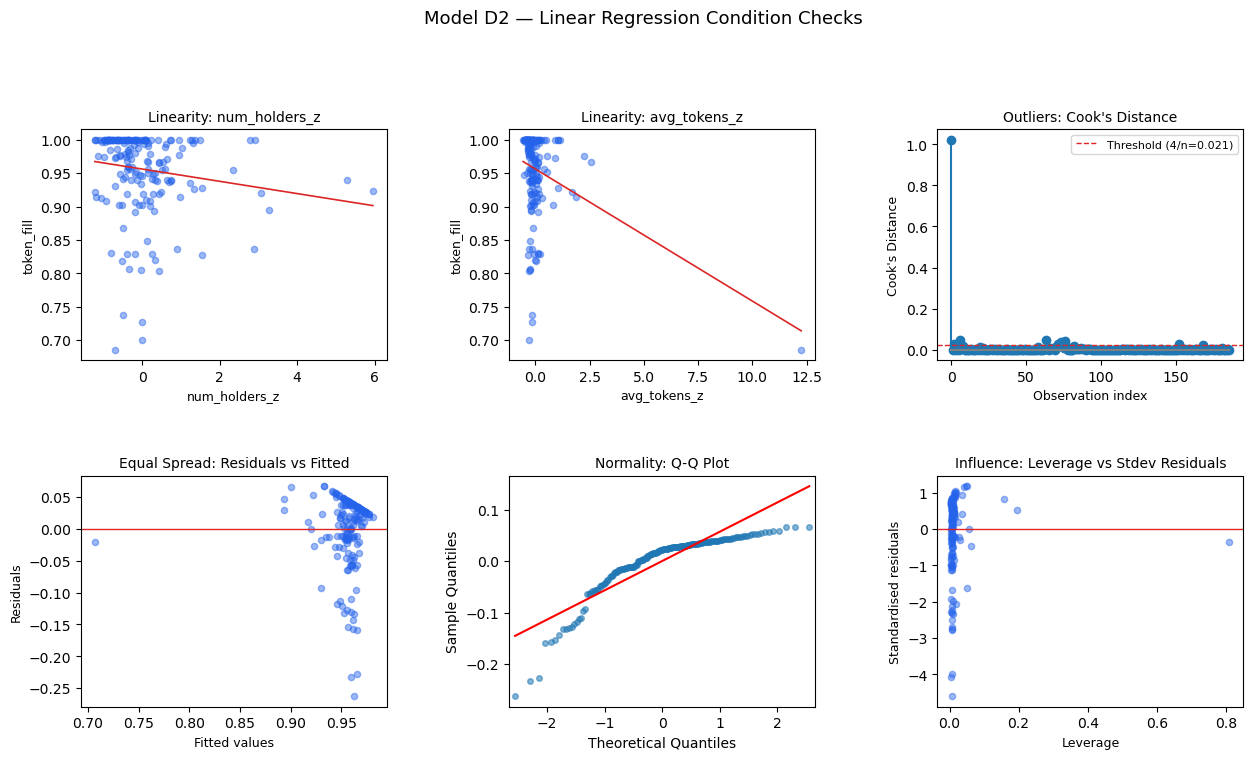

In [74]:
fig_d2 = plt.figure(figsize=(15, 12))
fig_d2.suptitle('Model D2 — Linear Regression Condition Checks', fontsize=13, y=0.98)
gs_d2 = gridspec.GridSpec(3, 3, figure=fig_d2, hspace=0.5, wspace=0.4)

# Linearity: num_holders_z
ax1 = fig_d2.add_subplot(gs_d2[0, 0])
ax1.scatter(df['num_holders_z'], y, alpha=0.45, s=20, color='#2563eb')
m, b = np.polyfit(df['num_holders_z'], y, 1)
xr = np.linspace(df['num_holders_z'].min(), df['num_holders_z'].max(), 100)
ax1.plot(xr, m * xr + b, color='#dc2626', linewidth=1.2)
ax1.set_xlabel('num_holders_z', fontsize=9)
ax1.set_ylabel('token_fill', fontsize=9)
ax1.set_title('Linearity: num_holders_z', fontsize=10)

# Linearity: avg_tokens_z
ax2 = fig_d2.add_subplot(gs_d2[0, 1])
ax2.scatter(df['avg_tokens_z'], y, alpha=0.45, s=20, color='#2563eb')
m2, b2 = np.polyfit(df['avg_tokens_z'], y, 1)
xr2 = np.linspace(df['avg_tokens_z'].min(), df['avg_tokens_z'].max(), 100)
ax2.plot(xr2, m2 * xr2 + b2, color='#dc2626', linewidth=1.2)
ax2.set_xlabel('avg_tokens_z', fontsize=9)
ax2.set_ylabel('token_fill', fontsize=9)
ax2.set_title('Linearity: avg_tokens_z', fontsize=10)

# Cook's distance
ax3 = fig_d2.add_subplot(gs_d2[0, 2])
ax3.stem(range(n_d2), cooks_d_d2, markerfmt='o', linefmt='C0-', basefmt='gray')
ax3.axhline(threshold_d2, color='#dc2626', linewidth=1,
            linestyle='--', label=f'Threshold (4/n={threshold_d2:.3f})')
ax3.set_xlabel('Observation index', fontsize=9)
ax3.set_ylabel("Cook's Distance", fontsize=9)
ax3.set_title("Outliers: Cook's Distance", fontsize=10)
ax3.legend(fontsize=8)

# Residuals vs Fitted
ax4 = fig_d2.add_subplot(gs_d2[1, 0])
ax4.scatter(fitted_d2, residuals_d2, alpha=0.45, s=20, color='#2563eb')
ax4.axhline(0, color='#dc2626', linewidth=1)
ax4.set_xlabel('Fitted values', fontsize=9)
ax4.set_ylabel('Residuals', fontsize=9)
ax4.set_title('Equal Spread: Residuals vs Fitted', fontsize=10)

# Q-Q plot
ax6 = fig_d2.add_subplot(gs_d2[1, 1])
sm.qqplot(residuals_d2, line='s', ax=ax6, alpha=0.55, markersize=4)
ax6.set_title('Normality: Q-Q Plot', fontsize=10)

# Leverage vs Stdev residuals
ax7 = fig_d2.add_subplot(gs_d2[1, 2])
ax7.scatter(leverage_d2, std_resid_d2, alpha=0.45, s=20, color='#2563eb')
ax7.axhline(0, color='#dc2626', linewidth=1)
ax7.set_xlabel('Leverage', fontsize=9)
ax7.set_ylabel('Standardised residuals', fontsize=9)
ax7.set_title('Influence: Leverage vs Stdev Residuals', fontsize=10)

plt.tight_layout()
plt.savefig("modeld.png")
plt.show()

In [26]:
for col in ['year_built', 'projected_return', 'num_images',
            'num_holders', 'avg_tokens']:
    df[f'{col}_z'] = zscore(df[col])
 
y = df['token_fill'].copy()

In [75]:
feature_cols_e1 = ['year_built_z', 'num_holders_z', 'avg_tokens_z']
 
X_e1 = df[feature_cols_e1].copy()
X_e1_const = sm.add_constant(X_e1)
 
model_e1 = sm.OLS(y, X_e1_const).fit(cov_type='HC3')
 
print("=" * 65)
print("MODEL E1 — year_built_z + num_holders_z + avg_tokens_z (HC3)")
print("=" * 65)
print(model_e1.summary())

MODEL E1 — year_built_z + num_holders_z + avg_tokens_z (HC3)
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     5.638
Date:                Mon, 13 Apr 2026   Prob (F-statistic):            0.00102
Time:                        19:33:01   Log-Likelihood:                 271.89
No. Observations:                 187   AIC:                            -535.8
Df Residuals:                     183   BIC:                            -522.9
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

In [76]:
feature_cols_e2 = ['year_built_z', 'num_holders_z', 'avg_tokens_z', 'num_images_z']
 
X_e2 = df[feature_cols_e2].copy()
X_e2_const = sm.add_constant(X_e2)
 
model_e2 = sm.OLS(y, X_e2_const).fit(cov_type='HC3')
 
print("\n" + "=" * 65)
print("MODEL E2 — E1 + num_images_z (HC3)")
print("=" * 65)
print(model_e2.summary())


MODEL E2 — E1 + num_images_z (HC3)
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.170
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     6.786
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           4.11e-05
Time:                        19:33:07   Log-Likelihood:                 274.13
No. Observations:                 187   AIC:                            -538.3
Df Residuals:                     182   BIC:                            -522.1
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const     

In [77]:
feature_cols_e3 = ['year_built_z', 'num_holders_z', 'avg_tokens_z', 'projected_return_z']
 
X_e3 = df[feature_cols_e3].copy()
X_e3_const = sm.add_constant(X_e3)
 
model_e3 = sm.OLS(y, X_e3_const).fit(cov_type='HC3')
 
print("\n" + "=" * 65)
print("MODEL E3 — E1 + projected_return_z (HC3)")
print("=" * 65)
print(model_e3.summary())


MODEL E3 — E1 + projected_return_z (HC3)
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.133
Method:                 Least Squares   F-statistic:                     4.555
Date:                Mon, 13 Apr 2026   Prob (F-statistic):            0.00157
Time:                        19:33:14   Log-Likelihood:                 272.08
No. Observations:                 187   AIC:                            -534.2
Df Residuals:                     182   BIC:                            -518.0
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

In [78]:
feature_cols_e4 = [
    'year_built_z', 'projected_return_z', 'num_images_z',
    'num_holders_z', 'avg_tokens_z'
]
 
X_e4 = df[feature_cols_e4].copy()
X_e4_const = sm.add_constant(X_e4)
 
model_e4 = sm.OLS(y, X_e4_const).fit(cov_type='HC3')
 
print("\n" + "=" * 65)
print("MODEL E4 — all near-significant variables")
print("=" * 65)
print(model_e4.summary())


MODEL E4 — all near-significant variables
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.170
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     5.419
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           0.000114
Time:                        19:33:18   Log-Likelihood:                 274.14
No. Observations:                 187   AIC:                            -536.3
Df Residuals:                     181   BIC:                            -516.9
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

In [79]:
feature_cols_e5 = [
    'year_built_z', 'num_images_z',
    'num_holders_z', 'avg_tokens_z', 'projected_annual_cash_flow_z'
]
 
X_e5 = df[feature_cols_e5].copy()
X_e5_const = sm.add_constant(X_e5)
 
model_e5 = sm.OLS(y, X_e5_const).fit(cov_type='HC3')
 
print("\n" + "=" * 65)
print("MODEL E5")
print("=" * 65)
print(model_e5.summary())


MODEL E5
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.173
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     5.849
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           4.92e-05
Time:                        19:33:21   Log-Likelihood:                 274.41
No. Observations:                 187   AIC:                            -536.8
Df Residuals:                     181   BIC:                            -517.4
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const 

In [80]:
feature_cols_e6 = ['num_images_z', 'num_holders_z', 'avg_tokens_z', 'underlying_asset_price_z']
 
X_e6 = df[feature_cols_e6].copy()
X_e6_const = sm.add_constant(X_e6)
 
model_e6 = sm.OLS(y, X_e6_const).fit(cov_type='HC3')
 
print("\n" + "=" * 65)
print("MODEL E6")
print("=" * 65)
print(model_e6.summary())


MODEL E6
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     10.45
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.21e-07
Time:                        19:33:25   Log-Likelihood:                 274.35
No. Observations:                 187   AIC:                            -538.7
Df Residuals:                     182   BIC:                            -522.5
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const         

In [81]:
print(df['underlying_asset_price'].mean())
print(df['underlying_asset_price'].std())

371691.08727272734
586121.6053069746


In [82]:
print("Variance Inflation Factors")
vif_e6 = pd.DataFrame({
    'Variable': feature_cols_e6,
    'VIF': [variance_inflation_factor(X_e6_const.values, i + 1)
            for i in range(len(feature_cols_e6))]
}).sort_values('VIF', ascending=False)
print(vif_e6.to_string(index=False))

Variance Inflation Factors
                Variable      VIF
underlying_asset_price_z 1.452602
            avg_tokens_z 1.301021
            num_images_z 1.159203
           num_holders_z 1.024195


In [83]:
print("Pearson r (Y vs each predictor)")
for col in ['num_holders_z', 'avg_tokens_z', 'num_images_z', 'underlying_asset_price_z']:
    mask = df[col].notna() & y.notna()
    r, p = stats.pearsonr(df[col][mask], y[mask])
    print(f"  {col}: r = {r:.4f}, p = {p:.4f}")

Pearson r (Y vs each predictor)
  num_holders_z: r = -0.1499, p = 0.0405
  avg_tokens_z: r = -0.3225, p = 0.0000
  num_images_z: r = 0.0943, p = 0.1994
  underlying_asset_price_z: r = -0.0194, p = 0.7926


In [84]:
fitted_e6 = model_e6.fittedvalues
residuals_e6 = model_e6.resid
std_resid_e6 = residuals_e6 / residuals_e6.std()
n_e6  = len(y)
bins_e6 = pd.qcut(fitted_e6, q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

influence_e6 = model_e6.get_influence()
cooks_d_e6 = influence_e6.cooks_distance[0]
leverage_e6 = influence_e6.hat_matrix_diag
threshold_e6 = 4 / n_e6

print(f"\nOutliers — Cook's Distance")
print(f"  Threshold (4/n = 4/{n_e6}): {threshold_e6:.4f}")
print(f"  Observations exceeding threshold: {(cooks_d_e6 > threshold_e6).sum()}")
print(f"  Top 5 Cook's D:")
for i in np.argsort(cooks_d_e6)[::-1][:5]:
    print(f"    Obs {i:>4} | Cook's D = {cooks_d_e6[i]:.4f} | "
          f"property_id = {df['property_id'].iloc[i]} | "
          f"token_fill = {y.iloc[i]:.4f} | "
          f"num_holders = {df['num_holders'].iloc[i]:.0f} | "
          f"avg_tokens = {df['avg_tokens'].iloc[i]:.1f} | "
          f"asset_price = {df['underlying_asset_price'].iloc[i]:.0f}")


Outliers — Cook's Distance
  Threshold (4/n = 4/187): 0.0214
  Observations exceeding threshold: 7
  Top 5 Cook's D:
    Obs    0 | Cook's D = 0.5154 | property_id = 01K1VKTF50B18YPKEKKMNT988E | token_fill = 0.6856 | num_holders = 60 | avg_tokens = 406.0 | asset_price = 3793150
    Obs   13 | Cook's D = 0.0507 | property_id = 01J1ZRN9EZVYA08NMNVHT2BPC1 | token_fill = 0.9954 | num_holders = 272 | avg_tokens = 15.2 | asset_price = 2320500
    Obs   76 | Cook's D = 0.0424 | property_id = 01FKPEZVFSD6KDYN5DY5Y7Z2AE | token_fill = 0.6999 | num_holders = 134 | avg_tokens = 10.9 | asset_price = 97000
    Obs   73 | Cook's D = 0.0288 | property_id = 01G0364A8VB2BH861CN84JR5KJ | token_fill = 0.7379 | num_holders = 82 | avg_tokens = 15.1 | asset_price = 93885
    Obs    6 | Cook's D = 0.0280 | property_id = 01FKVM5P0WS9JPMCDZ1GB1RQQG | token_fill = 0.8368 | num_holders = 440 | avg_tokens = 10.5 | asset_price = 255000


In [85]:
bp_lm, bp_lm_p, _, _ = het_breuschpagan(residuals_e6, X_e6_const)
print(f"Equal Spread (Homoscedasticity)")
print(f"  Breusch-Pagan LM: {bp_lm:.4f}, p-value: {bp_lm_p:.4f}")
print(f"  {'Heteroscedasticity detected (p<0.05)' if bp_lm_p < 0.05 else 'No significant heteroscedasticity at 5% level'}")

Equal Spread (Homoscedasticity)
  Breusch-Pagan LM: 3.9304, p-value: 0.4155
  No significant heteroscedasticity at 5% level


/var/folders/j4/c8mt230n6rn5t0qj3jl08r3m0000gn/T/ipykernel_2472/4229474881.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


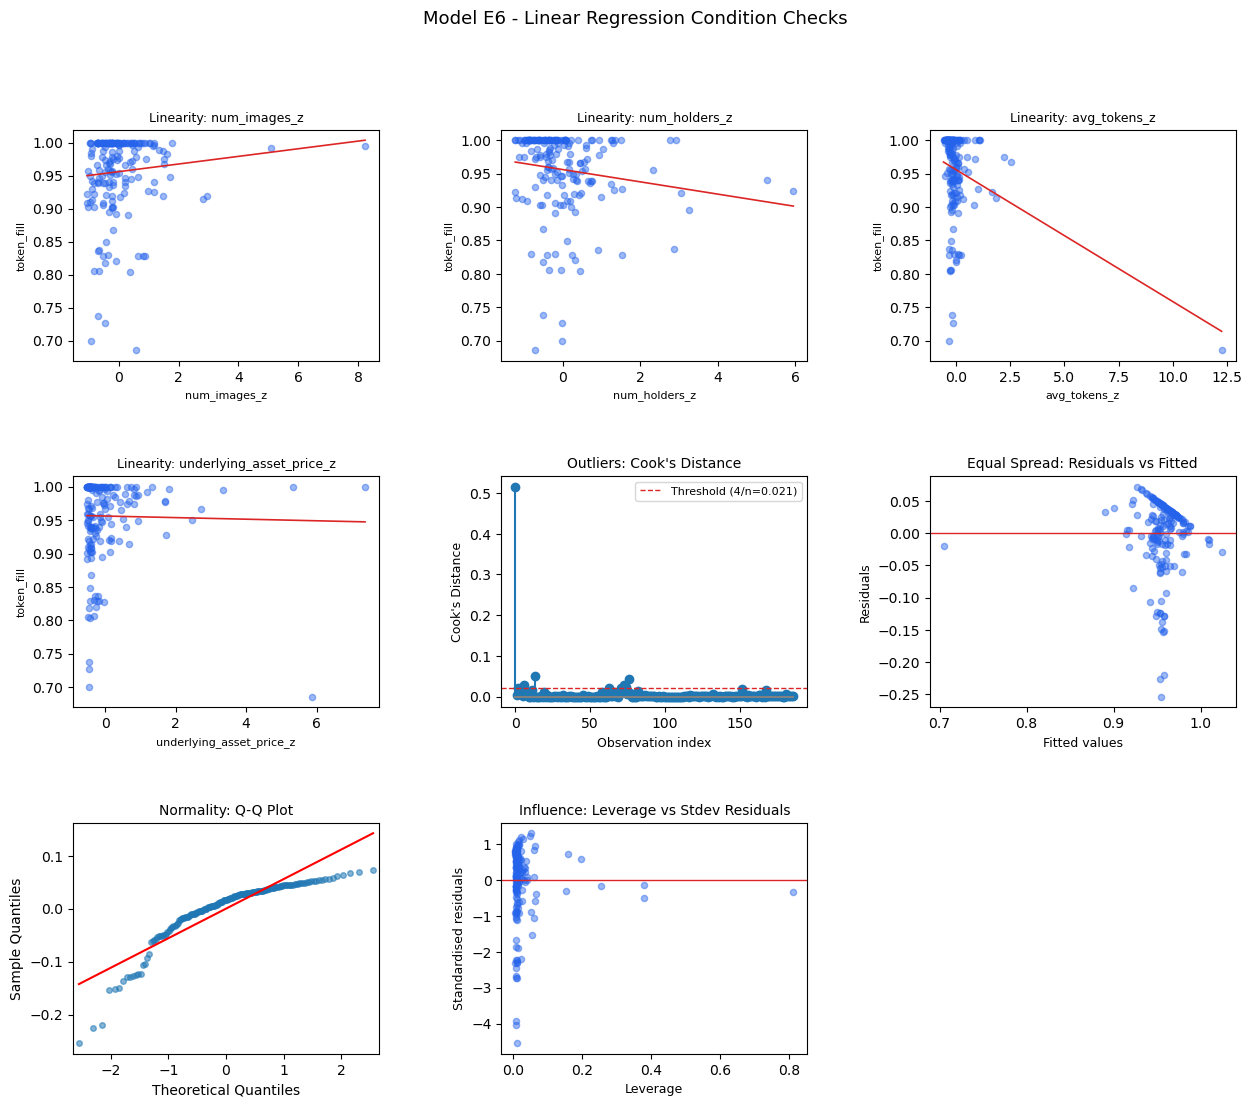

In [86]:
fig = plt.figure(figsize=(15, 12))
fig.suptitle('Model E6 - Linear Regression Condition Checks', fontsize=13, y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

# Linearity: first 3 predictors
for idx, col in enumerate(['num_images_z', 'num_holders_z', 'avg_tokens_z']):
    ax = fig.add_subplot(gs[0, idx])
    ax.scatter(df[col], y, alpha=0.45, s=20, color='#2563eb')
    m, b = np.polyfit(df[col], y, 1)
    xr = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(xr, m * xr + b, color='#dc2626', linewidth=1.2)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('token_fill', fontsize=8)
    ax.set_title(f'Linearity: {col}', fontsize=9)

# 4th predictor linearity
ax_extra = fig.add_subplot(gs[1, 0])
ax_extra.scatter(df['underlying_asset_price_z'], y, alpha=0.45, s=20, color='#2563eb')
m4, b4 = np.polyfit(df['underlying_asset_price_z'], y, 1)
xr4 = np.linspace(df['underlying_asset_price_z'].min(), df['underlying_asset_price_z'].max(), 100)
ax_extra.plot(xr4, m4 * xr4 + b4, color='#dc2626', linewidth=1.2)
ax_extra.set_xlabel('underlying_asset_price_z', fontsize=8)
ax_extra.set_ylabel('token_fill', fontsize=8)
ax_extra.set_title('Linearity: underlying_asset_price_z', fontsize=9)

# Cook's distance
ax4 = fig.add_subplot(gs[1, 1])
ax4.stem(range(n_e6), cooks_d_e6, markerfmt='o', linefmt='C0-', basefmt='gray')
ax4.axhline(threshold_e6, color='#dc2626', linewidth=1,
            linestyle='--', label=f'Threshold (4/n={threshold_e6:.3f})')
ax4.set_xlabel('Observation index', fontsize=9)
ax4.set_ylabel("Cook's Distance", fontsize=9)
ax4.set_title("Outliers: Cook's Distance", fontsize=10)
ax4.legend(fontsize=8)

# Residuals vs Fitted
ax5 = fig.add_subplot(gs[1, 2])
ax5.scatter(fitted_e6, residuals_e6, alpha=0.45, s=20, color='#2563eb')
ax5.axhline(0, color='#dc2626', linewidth=1)
ax5.set_xlabel('Fitted values', fontsize=9)
ax5.set_ylabel('Residuals', fontsize=9)
ax5.set_title('Equal Spread: Residuals vs Fitted', fontsize=10)

# Q-Q plot
ax7 = fig.add_subplot(gs[2, 0])
sm.qqplot(residuals_e6, line='s', ax=ax7, alpha=0.55, markersize=4)
ax7.set_title('Normality: Q-Q Plot', fontsize=10)

# Leverage vs Std residuals
ax8 = fig.add_subplot(gs[2, 1])
ax8.scatter(leverage_e6, std_resid_e6, alpha=0.45, s=20, color='#2563eb')
ax8.axhline(0, color='#dc2626', linewidth=1)
ax8.set_xlabel('Leverage', fontsize=9)
ax8.set_ylabel('Standardised residuals', fontsize=9)
ax8.set_title('Influence: Leverage vs Stdev Residuals', fontsize=10)

plt.tight_layout()
plt.savefig("modele.png")
plt.show()

In [29]:
df['days_diff_z'] = zscore(df['days_diff'])

feature_cols_e7 = ['year_built_z','num_images_z','days_diff_z','num_holders_z', 'avg_tokens_z', 'underlying_asset_price_z']
 
X_e7 = df[feature_cols_e7].copy()
X_e7_const = sm.add_constant(X_e7)
 
model_e7 = sm.OLS(y, X_e7_const).fit(cov_type='HC3')
 
print("\n" + "=" * 65)
print("MODEL E7")
print("=" * 65)
print(model_e7.summary())


MODEL E7
                            OLS Regression Results                            
Dep. Variable:             token_fill   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.166
Method:                 Least Squares   F-statistic:                     6.542
Date:                Sun, 24 May 2026   Prob (F-statistic):           2.89e-06
Time:                        22:10:01   Log-Likelihood:                 276.77
No. Observations:                 187   AIC:                            -539.5
Df Residuals:                     180   BIC:                            -516.9
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const         

In [31]:
print("Variance Inflation Factors")
vif_e7 = pd.DataFrame({
    'Variable': feature_cols_e7,
    'VIF': [variance_inflation_factor(X_e7_const.values, i + 1)
            for i in range(len(feature_cols_e7))]
}).sort_values('VIF', ascending=False)
print(vif_e7.to_string(index=False))

Variance Inflation Factors
                Variable      VIF
underlying_asset_price_z 1.808559
            avg_tokens_z 1.479428
             days_diff_z 1.462937
            num_images_z 1.216702
            year_built_z 1.206637
           num_holders_z 1.100312


In [33]:
print("Pearson r (Y vs each predictor)")
for col in ['year_built_z', 'days_diff_z', 'num_holders_z', 'avg_tokens_z', 'num_images_z', 'underlying_asset_price_z']:
    mask = df[col].notna() & y.notna()
    r, p = stats.pearsonr(df[col][mask], y[mask])
    print(f"  {col}: r = {r:.4f}, p = {p:.4f}")

Pearson r (Y vs each predictor)
  year_built_z: r = 0.1479, p = 0.0434
  days_diff_z: r = 0.1123, p = 0.1259
  num_holders_z: r = -0.1499, p = 0.0405
  avg_tokens_z: r = -0.3225, p = 0.0000
  num_images_z: r = 0.0943, p = 0.1994
  underlying_asset_price_z: r = -0.0194, p = 0.7926


In [34]:
fitted_e7 = model_e7.fittedvalues
residuals_e7 = model_e7.resid
std_resid_e7 = residuals_e7 / residuals_e7.std()
n_e7 = len(y)
bins_e7 = pd.qcut(fitted_e7, q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

influence_e7 = model_e7.get_influence()
cooks_d_e7 = influence_e7.cooks_distance[0]
leverage_e7 = influence_e7.hat_matrix_diag
threshold_e7 = 4 / n_e7

print(f"\nOutliers — Cook's Distance")
print(f"  Threshold (4/n = 4/{n_e7}): {threshold_e7:.4f}")
print(f"  Observations exceeding threshold: {(cooks_d_e7 > threshold_e7).sum()}")
print(f"  Top 5 Cook's D:")
for i in np.argsort(cooks_d_e7)[::-1][:5]:
    print(f"    Obs {i:>4} | Cook's D = {cooks_d_e7[i]:.4f} | "
          f"property_id = {df['property_id'].iloc[i]} | "
          f"year_built = {df['year_built'].iloc[i]} | "
          f"days_diff = {df['days_diff'].iloc[i]:.1f} | "
          f"token_fill = {y.iloc[i]:.4f} | "
          f"num_holders = {df['num_holders'].iloc[i]:.0f} | "
          f"avg_tokens = {df['avg_tokens'].iloc[i]:.1f} | "
          f"asset_price = {df['underlying_asset_price'].iloc[i]:.0f}")


Outliers — Cook's Distance
  Threshold (4/n = 4/187): 0.0214
  Observations exceeding threshold: 9
  Top 5 Cook's D:
    Obs    0 | Cook's D = 1.8066 | property_id = 01K1VKTF50B18YPKEKKMNT988E | year_built = 1902.0 | days_diff = 289.0 | token_fill = 0.6856 | num_holders = 60 | avg_tokens = 406.0 | asset_price = 3793150
    Obs   13 | Cook's D = 0.0926 | property_id = 01J1ZRN9EZVYA08NMNVHT2BPC1 | year_built = 1978.0 | days_diff = 682.0 | token_fill = 0.9954 | num_holders = 272 | avg_tokens = 15.2 | asset_price = 2320500
    Obs   58 | Cook's D = 0.0552 | property_id = 01K1KEB3HS6VSQXXZG0Y7DKSCC | year_built = 1815.0 | days_diff = 272.0 | token_fill = 0.9752 | num_holders = 15 | avg_tokens = 90.4 | asset_price = 351750
    Obs    2 | Cook's D = 0.0506 | property_id = 01HH55NJSE80CHPE90B1RTRQRB | year_built = 1815.0 | days_diff = 846.0 | token_fill = 0.8276 | num_holders = 298 | avg_tokens = 10.1 | asset_price = 350000
    Obs   76 | Cook's D = 0.0325 | property_id = 01FKPEZVFSD6KDYN5DY5

In [36]:
from statsmodels.stats.diagnostic import het_breuschpagan
bp_lm, bp_lm_p, _, _ = het_breuschpagan(residuals_e7, X_e7_const)
print(f"Equal Spread (Homoscedasticity)")
print(f"  Breusch-Pagan LM: {bp_lm:.4f}, p-value: {bp_lm_p:.4f}")
print(f"  {'Heteroscedasticity detected (p<0.05)' if bp_lm_p < 0.05 else 'No significant heteroscedasticity at 5% level'}")

Equal Spread (Homoscedasticity)
  Breusch-Pagan LM: 6.5708, p-value: 0.3624
  No significant heteroscedasticity at 5% level


/var/folders/j4/c8mt230n6rn5t0qj3jl08r3m0000gn/T/ipykernel_16692/642621662.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


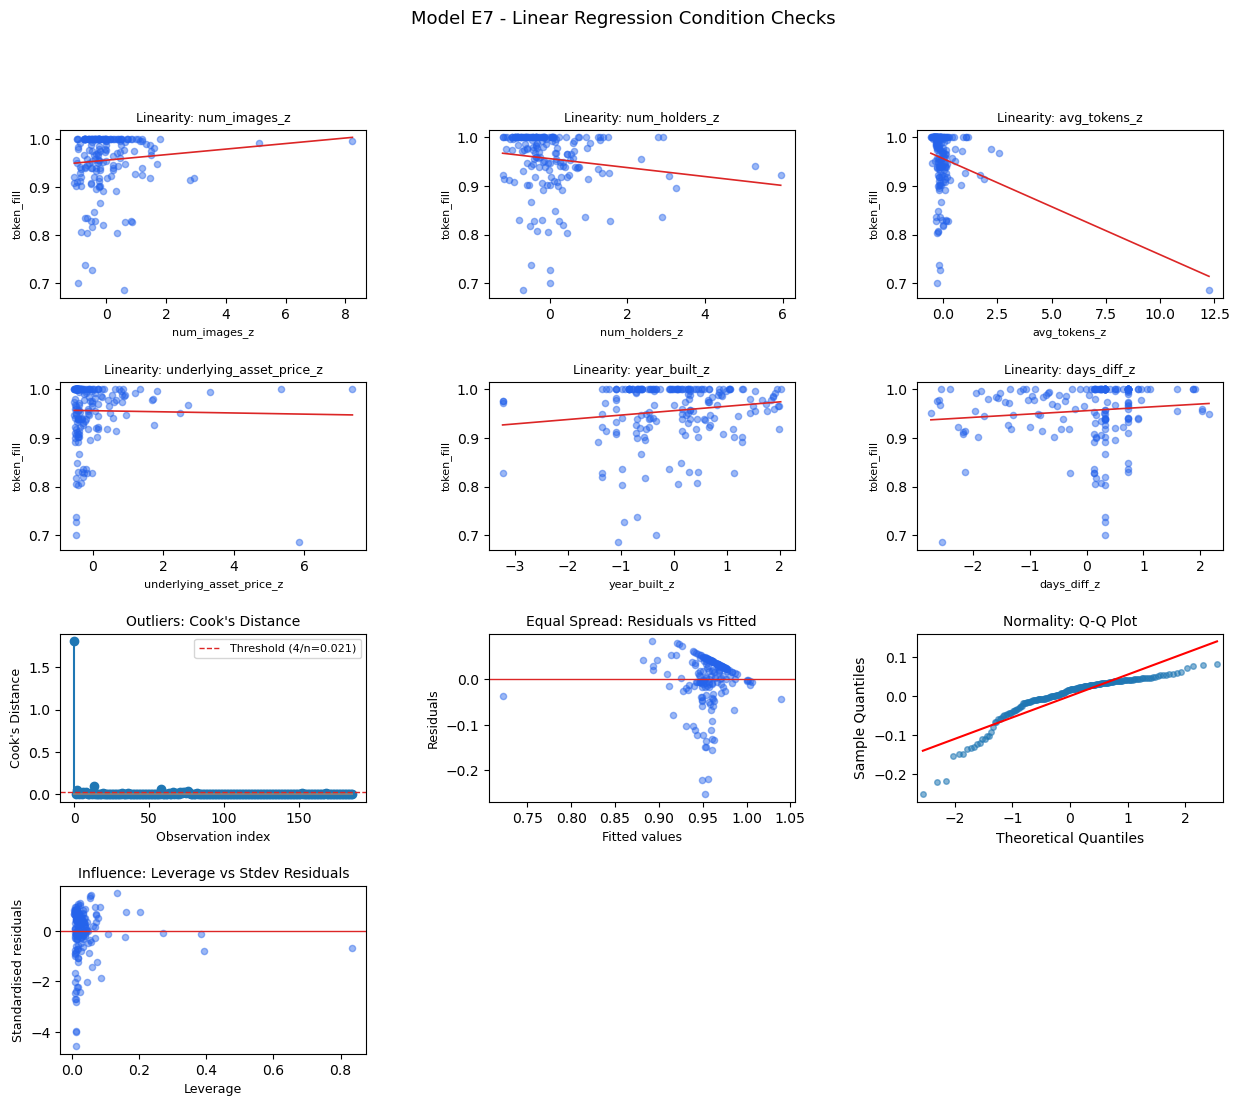

In [38]:
fig = plt.figure(figsize=(15, 12))
fig.suptitle('Model E7 - Linear Regression Condition Checks', fontsize=13, y=0.98)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.5, wspace=0.4)

# Linearity: first 3 predictors
for idx, col in enumerate(['num_images_z', 'num_holders_z', 'avg_tokens_z']):
    ax = fig.add_subplot(gs[0, idx])
    ax.scatter(df[col], y, alpha=0.45, s=20, color='#2563eb')
    m, b = np.polyfit(df[col], y, 1)
    xr = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(xr, m * xr + b, color='#dc2626', linewidth=1.2)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('token_fill', fontsize=8)
    ax.set_title(f'Linearity: {col}', fontsize=9)

# 4th predictor linearity
ax_extra = fig.add_subplot(gs[1, 0])
ax_extra.scatter(df['underlying_asset_price_z'], y, alpha=0.45, s=20, color='#2563eb')
m4, b4 = np.polyfit(df['underlying_asset_price_z'], y, 1)
xr4 = np.linspace(df['underlying_asset_price_z'].min(), df['underlying_asset_price_z'].max(), 100)
ax_extra.plot(xr4, m4 * xr4 + b4, color='#dc2626', linewidth=1.2)
ax_extra.set_xlabel('underlying_asset_price_z', fontsize=8)
ax_extra.set_ylabel('token_fill', fontsize=8)
ax_extra.set_title('Linearity: underlying_asset_price_z', fontsize=9)

# 5th predictor linearity
ax_extra = fig.add_subplot(gs[1, 1])
ax_extra.scatter(df['year_built_z'], y, alpha=0.45, s=20, color='#2563eb')
m4, b4 = np.polyfit(df['year_built_z'], y, 1)
xr4 = np.linspace(df['year_built_z'].min(), df['year_built_z'].max(), 100)
ax_extra.plot(xr4, m4 * xr4 + b4, color='#dc2626', linewidth=1.2)
ax_extra.set_xlabel('year_built_z', fontsize=8)
ax_extra.set_ylabel('token_fill', fontsize=8)
ax_extra.set_title('Linearity: year_built_z', fontsize=9)

# 6th predictor linearity
ax_extra = fig.add_subplot(gs[1, 2])
ax_extra.scatter(df['days_diff_z'], y, alpha=0.45, s=20, color='#2563eb')
m4, b4 = np.polyfit(df['days_diff_z'], y, 1)
xr4 = np.linspace(df['days_diff_z'].min(), df['days_diff_z'].max(), 100)
ax_extra.plot(xr4, m4 * xr4 + b4, color='#dc2626', linewidth=1.2)
ax_extra.set_xlabel('days_diff_z', fontsize=8)
ax_extra.set_ylabel('token_fill', fontsize=8)
ax_extra.set_title('Linearity: days_diff_z', fontsize=9)

# Cook's distance
ax4 = fig.add_subplot(gs[2, 0])
ax4.stem(range(n_e7), cooks_d_e7, markerfmt='o', linefmt='C0-', basefmt='gray')
ax4.axhline(threshold_e7, color='#dc2626', linewidth=1,
            linestyle='--', label=f'Threshold (4/n={threshold_e7:.3f})')
ax4.set_xlabel('Observation index', fontsize=9)
ax4.set_ylabel("Cook's Distance", fontsize=9)
ax4.set_title("Outliers: Cook's Distance", fontsize=10)
ax4.legend(fontsize=8)

# Residuals vs Fitted
ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(fitted_e7, residuals_e7, alpha=0.45, s=20, color='#2563eb')
ax5.axhline(0, color='#dc2626', linewidth=1)
ax5.set_xlabel('Fitted values', fontsize=9)
ax5.set_ylabel('Residuals', fontsize=9)
ax5.set_title('Equal Spread: Residuals vs Fitted', fontsize=10)

# Q-Q plot
ax7 = fig.add_subplot(gs[2, 2])
sm.qqplot(residuals_e7, line='s', ax=ax7, alpha=0.55, markersize=4)
ax7.set_title('Normality: Q-Q Plot', fontsize=10)

# Leverage vs Std residuals
ax8 = fig.add_subplot(gs[3, 0])
ax8.scatter(leverage_e7, std_resid_e7, alpha=0.45, s=20, color='#2563eb')
ax8.axhline(0, color='#dc2626', linewidth=1)
ax8.set_xlabel('Leverage', fontsize=9)
ax8.set_ylabel('Standardised residuals', fontsize=9)
ax8.set_title('Influence: Leverage vs Stdev Residuals', fontsize=10)

plt.tight_layout()
plt.savefig("modele7.png")
plt.show()

In [4]:
df_stats = pd.read_excel('properties_v7_with_ratios.xlsx')
df_stats.describe().to_clipboard()

In [6]:
df_stats['token_fill']= 1-df_stats['token_ratio']
df_stats['token_fill'].describe()

count    193.000000
mean       0.955691
std        0.062300
min        0.685578
25%        0.938718
50%        0.979354
75%        1.000000
max        1.000000
Name: token_fill, dtype: float64

In [8]:
holders = pd.read_excel('holders_v7.xlsx')
holders['tokens_held'] = pd.to_numeric(holders['tokens_held'], errors='coerce')
 
# Merge tokens_total from properties 
holders = holders.merge(
    df_stats[['property_id', 'tokens_total']].drop_duplicates(),
    on='property_id', how='left'
)
holders['tokens_total'] = pd.to_numeric(holders['tokens_total'], errors='coerce')
holders['pct_held'] = holders['tokens_held'] / holders['tokens_total']
 
# Exclude holders with > 15% of total supply per property
n_before = len(holders)
holders_clean = holders[holders['pct_held'] <= 0.15].copy()
n_excluded = n_before - len(holders_clean)
print(f"Holders file: {n_before} rows")
print(f"  Excluded (pct_held > 15% of supply): {n_excluded} rows")
print(f"  Retained: {len(holders_clean)} rows")
print(f"Properties in holders file: {holders_clean['property_id'].nunique()}")

Holders file: 25613 rows
  Excluded (pct_held > 15% of supply): 311 rows
  Retained: 25302 rows
Properties in holders file: 192


In [9]:
holder_metrics = holders_clean.groupby('property_id').agg(
    num_holders   = ('holder_address', 'nunique'),
    avg_tokens    = ('tokens_held', 'mean'),
    median_tokens = ('tokens_held', 'median'),
).reset_index()
 
print(f"\nHolder metrics computed for {len(holder_metrics)} properties")
print("\nDescriptive statistics — holder metrics")
print(holder_metrics[['num_holders', 'avg_tokens', 'median_tokens']].describe().round(2))


Holder metrics computed for 192 properties

Descriptive statistics — holder metrics
       num_holders  avg_tokens  median_tokens
count       192.00      192.00         192.00
mean        131.78       20.83           3.36
std         106.07       31.47           4.09
min           5.00        2.67           1.00
25%          69.00       11.40           2.00
50%         111.50       15.04           3.00
75%         160.50       21.62           3.50
max         765.00      406.00          45.00


In [10]:
collection_date = pd.to_datetime('2026-03-26')

df_stats['Date'] = pd.to_datetime(
    df_stats['sellout_date'],
    format='%m/%d/%y',
    errors='coerce'
)

df_stats["days_diff"] = (collection_date - df_stats["Date"]).dt.days

In [11]:
df_stats["days_diff"].describe()

count     193.000000
mean      755.455959
std       212.781699
min       190.000000
25%       659.000000
50%       828.000000
75%       912.000000
max      1208.000000
Name: days_diff, dtype: float64